# Team Project Submission #3 - Pytorch for Natural Language Processing or for MNIST classification

**Course:** CS 506 - Programming for Computing

** Topic:** Introduction to PyTorch and its applications

**Student/Team:** Anushree Raut, Titus Michael Masele, Amandeep Singh Saran

**Date:** 03-19-2026

Tutorial Goals

By the end of this tutorial, learners will:

1. Understand the basics of deep learning using PyTorch

2. Learn how to load and preprocess image datasets

3. Build a neural network model from scratch

4. Train and evaluate a model

5. Visualize performance metrics

6. Make predictions using a trained model

Learning Outcomes

After completing this tutorial, students will be able to:

1. Explain how neural networks work at a basic level

2. Implement a classification model using PyTorch

3. Use datasets like MNIST dataset

4. Train models using loss functions and optimizers

5. Evaluate model accuracy

6. Apply learned concepts to other ML problems

What PyTorch is:

PyTorch is an open-source library used for machine learning and deep learning. It was developed by Meta AI.

In simple terms, PyTorch helps you:

1. Work with tensors (like advanced arrays, similar to NumPy but faster and GPU-enabled)

2. Build neural networks (models that learn patterns from data)

3. Automatically compute gradients using Autograd (needed to train models)

One of its biggest strengths is its dynamic computation graph, meaning:

1. You can write models like normal Python code

2. It’s flexible and easy to debug


Why PyTorch is used:

PyTorch is widely used because it makes machine learning easier, faster, and more flexible.

1. Easy to learn and use

Syntax is very close to Python

Simple to understand compared to some older frameworks

2. Flexible (dynamic graphs)

You can change your model while it’s running

Great for research and experimentation

3. Strong community and support

Many tutorials, examples, and prebuilt models available

Widely used in academia and industry

4. GPU acceleration

Runs on GPUs for faster training of large models

Essential for deep learning tasks

5. Used in real-world applications

Image recognition

Natural language processing (like chatbots)

Recommendation systems

Self-driving car research

6. Good for both research and production

Researchers like it for flexibility

Engineers can deploy models using tools like TorchScript

Tensors:

1. Tensors are multi-dimensional arrays used in PyTorch to store and process data.

2. They support fast operations and can run on GPUs for efficient computation.

Autograd:

1. Autograd automatically computes gradients needed for training neural networks.

2. It tracks operations on tensors and performs backpropagation automatically.

Neural Networks:

1. Neural networks are models made of layers that learn patterns from data.
2. In PyTorch, they are built using modules like nn.Module and trained using data.

In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# Create a tensor
x = torch.tensor([[1, 2], [3, 4]])

# Print tensor
print(x)

# Shape of tensor
print(x.shape)

tensor([[1, 2],
        [3, 4]])
torch.Size([2, 2])


In [3]:
# Addition
y = x + x
print(y)

# Matrix multiplication
z = torch.matmul(x, x)
print(z)

tensor([[2, 4],
        [6, 8]])
tensor([[ 7, 10],
        [15, 22]])


In [5]:
from torchvision import datasets, transforms
import os

transform = transforms.ToTensor()

data_path = os.path.expanduser("~/mnist_data")

train_data = datasets.MNIST(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


In [6]:
# Create DataLoader
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

In [7]:
# Define neural network
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten image
        x = self.relu(self.fc1(x))  # Hidden layer
        x = self.fc2(x)  # Output layer
        return x

# Initialize model
model = NeuralNet()

In [8]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# Training the model
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    
    for images, labels in train_loader:
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()  # Clear gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 563.4592
Epoch 2, Loss: 250.6441
Epoch 3, Loss: 170.3221
Epoch 4, Loss: 127.2684
Epoch 5, Loss: 97.6186


In [10]:
# Evaluate model
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 97.41%


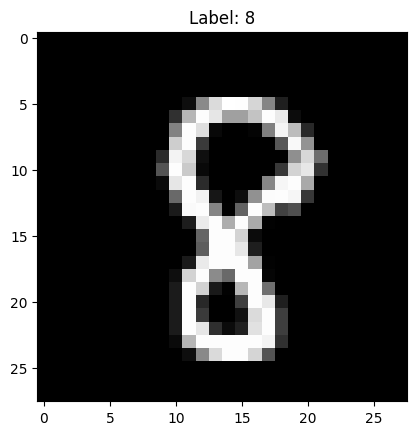

In [11]:
# Plot a sample image
images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0]}")
plt.show()

# Conclusion

In this notebook, we learned:
1. Tensor operations
2. Data loading
3. Neural network construction
4. Training using autograd

PyTorch provides a flexible and powerful framework for deep learning.